In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# EDA — SPR 2026 BI-RADS Report NLP Challenge

## 0) Imports y configuración

In [1]:
# =========================
# 0. Imports & Config
# =========================
import os
import re
import gc
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", 100)

## 1) Carga de Datos

In [2]:
# =========================
# 1. Load data
# =========================
TRAIN_DIR = "/kaggle/input/datasets/damontoyat/bi-rads-train"
TEST_DIR  = "/kaggle/input/datasets/damontoyat/bi-rads-test"

train_path = os.path.join(TRAIN_DIR, "train.csv")
test_path  = os.path.join(TEST_DIR, "test.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head(3))
display(test.head(3))

train shape: (18272, 3)
test shape : (4, 2)


,ID,report,target
0,Acc1,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rImagens de mamografias a...,2
1,Acc3,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias anteriores n...,2
2,Acc5,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao exame de <...,2


,ID,report
0,Acc0,"Indicação clínica: rastreamento.Achados:Mamas parcialmente lipossubstituídas.Nódulo irregular localizado no quadrante superolateral da mama direita, medindo 2,8 cm, que à ultrassonografia complementar corresponde a nódulo espiculado associado a distorção arquitetural. Este foi submetido a core b..."
1,Acc2,"Indicação clínica: rastreamento.Achados:Mamas parcialmente lipossubstituídas.Calcificações benignas esparsas.Não se observam calcificações suspeitas agrupadas.As regiões axilares não apresentam alterações significativas.Análise comparativa:Em relação ao exame de <DATA> , não se observam alteraçõ..."
2,Acc4,Indicação clínica: rastreamento.Achados:Mamas parcialmente lipossubstituídas.Marcador radiopaco em lesão cutânea à direita.Não se observam calcificações suspeitas agrupadas.As regiões axilares não apresentam alterações significativas.Análise comparativa:Mamografias anteriores não disponíveis par...


## 2) Inspeccion Basica

In [3]:
# =========================
# 2. Basic inspection
# =========================
print("Train columns:", train.columns.tolist())
print("Test columns :", test.columns.tolist())
print("\nTrain dtypes:\n", train.dtypes)
print("\nTest dtypes:\n", test.dtypes)

print("\nMissing values - train:")
print(train.isna().sum())

print("\nMissing values - test:")
print(test.isna().sum())

print("\nDuplicated rows in train:", train.duplicated().sum())
print("Duplicated rows in test :", test.duplicated().sum())

if "id" in train.columns:
    print("\nDuplicated train ids:", train["id"].duplicated().sum())
if "id" in test.columns:
    print("Duplicated test ids :", test["id"].duplicated().sum())

if "report" in train.columns:
    print("\nDuplicated train reports:", train["report"].duplicated().sum())
if "report" in test.columns:
    print("Duplicated test reports :", test["report"].duplicated().sum())

Train columns: ['ID', 'report', 'target']
Test columns : ['ID', 'report']

Train dtypes:
 ID        object
report    object
target     int64
dtype: object

Test dtypes:
 ID        object
report    object
dtype: object

Missing values - train:
ID        0
report    0
target    0
dtype: int64

Missing values - test:
ID        0
report    0
dtype: int64

Duplicated rows in train: 0
Duplicated rows in test : 0

Duplicated train reports: 9141
Duplicated test reports : 0


## 3) Verificacion del Target

Unique target values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Target counts:


target
0      610
1      693
2    15968
3      713
4      214
5       29
6       45
Name: count, dtype: int64

,count,percent
target,,
0,610,3.34
1,693,3.79
2,15968,87.39
3,713,3.90
4,214,1.17
5,29,0.16
6,45,0.25


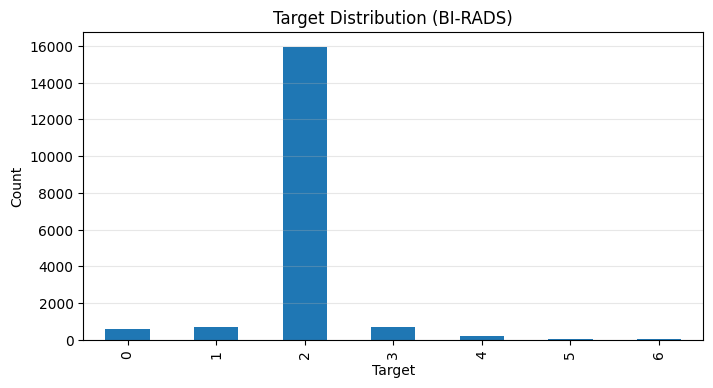

In [4]:
# =========================
# 3. Target inspection
# =========================
print("Unique target values:", sorted(train["target"].unique()))
print("\nTarget counts:")
display(train["target"].value_counts().sort_index())

target_dist = train["target"].value_counts().sort_index()
target_pct = (target_dist / len(train) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_dist,
    "percent": target_pct
})

display(target_summary)

plt.figure(figsize=(8, 4))
target_dist.plot(kind="bar")
plt.title("Target Distribution (BI-RADS)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4) Features de longitud de texto

In [5]:
# =========================
# 4. Text length features
# =========================
def add_text_features(df, text_col="report"):
    df = df.copy()
    df["report"] = df[text_col].fillna("")
    df["n_chars"] = df["report"].apply(len)
    df["n_words"] = df["report"].apply(lambda x: len(x.split()))
    df["n_sent_approx"] = df["report"].apply(lambda x: len(re.split(r"[.!?]+", x)) if x.strip() else 0)
    df["n_upper"] = df["report"].apply(lambda x: sum(c.isupper() for c in x))
    df["upper_ratio"] = df.apply(lambda r: r["n_upper"] / r["n_chars"] if r["n_chars"] > 0 else 0, axis=1)
    return df

train_eda = add_text_features(train, "report")
test_eda  = add_text_features(test, "report")

display(train_eda[["n_chars", "n_words", "n_sent_approx", "upper_ratio"]].describe().T)
display(test_eda[["n_chars", "n_words", "n_sent_approx", "upper_ratio"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
n_chars,18272.0,400.666594,103.232834,183.000000,332.000000,364.000000,423.000000,1622.00000
n_words,18272.0,44.896618,14.217563,19.000000,36.000000,40.000000,48.000000,234.00000
n_sent_approx,18272.0,7.373030,1.003072,2.000000,7.000000,7.000000,8.000000,42.00000
upper_ratio,18272.0,0.028169,0.007403,0.010843,0.023324,0.025916,0.033241,0.21573


,count,mean,std,min,25%,50%,75%,max
n_chars,4.0,435.750000,145.520617,314.000000,317.000000,409.000000,527.750000,611.000000
n_words,4.0,46.000000,19.270011,29.000000,29.750000,44.500000,60.750000,66.000000
n_sent_approx,4.0,7.250000,1.258306,6.000000,6.750000,7.000000,7.500000,9.000000
upper_ratio,4.0,0.028572,0.006758,0.022913,0.024596,0.026579,0.030554,0.038217


### Distribuciones Generales

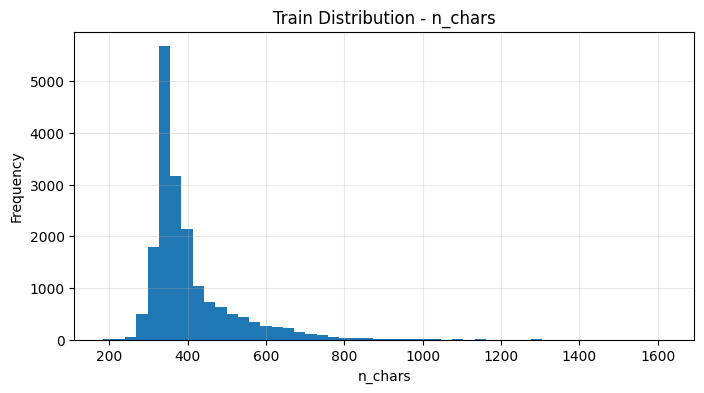

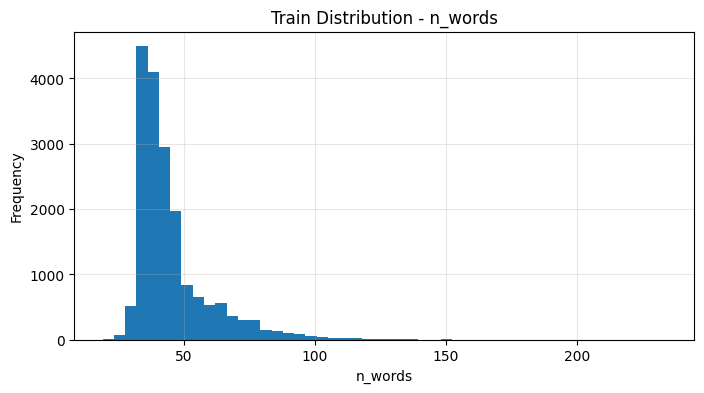

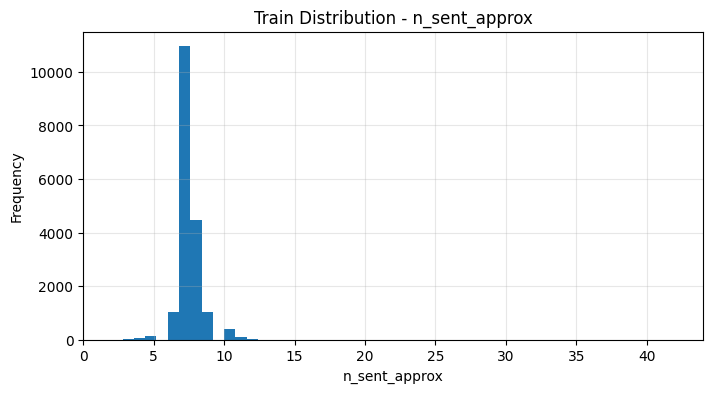

In [6]:
# =========================
# 4A. Length distributions
# =========================
for col in ["n_chars", "n_words", "n_sent_approx"]:
    plt.figure(figsize=(8, 4))
    plt.hist(train_eda[col], bins=50)
    plt.title(f"Train Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

### Longitud por Clase

n_chars                                  n_words                    \
              mean median         std  min   max       mean median        std   
target                                                                          
0       496.568852  482.0   96.998025  226   890  57.250820   55.0  13.158415   
1       315.304473  307.0   40.878198  210   726  34.672439   34.0   6.051638   
2       390.585984  361.0   89.852734  183  1622  43.431112   40.0  12.352362   
3       561.166900  532.0  139.948883  193  1287  67.612903   64.0  19.563250   
4       548.084112  520.0  144.420852  255   969  65.985981   61.0  20.207255   
5       557.482759  515.0  145.568497  359  1140  67.827586   61.0  19.833357   
6       647.133333  614.0  164.476249  334  1153  79.911111   75.0  22.555812   

                n_sent_approx                           
       min  max          mean median       std min max  
target                                                  
0       25  116      7.716393    8.0  1.657909   3  36  
1       22   88      6.033189    6.0  0.472107   3   9  
2       19  234      7.376065    7.0  0.815655   2  14  
3       24  211      8.061711    8.0  1.875809   2  42  
4       33  122      7.971963    8.0  2.674722   4  42  
5       47  148      8.034483    8.0  1.267246   5  12  
6       34  150      8.088889    8.0  1.443201   5  11

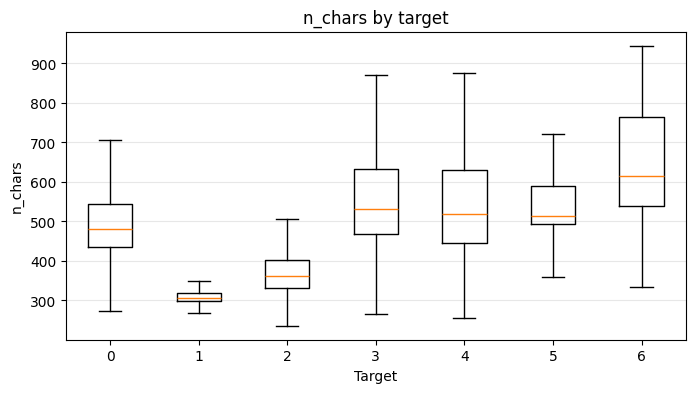

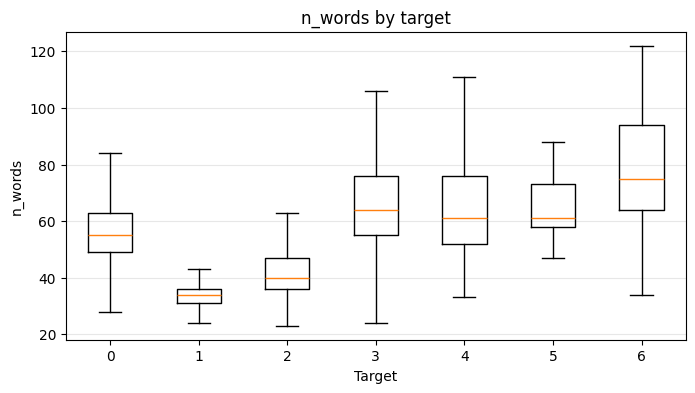

In [7]:
# =========================
# 4B. Length by target
# =========================
length_by_target = (
    train_eda.groupby("target")[["n_chars", "n_words", "n_sent_approx"]]
    .agg(["mean", "median", "std", "min", "max"])
)

display(length_by_target)

for col in ["n_chars", "n_words"]:
    plt.figure(figsize=(8, 4))
    data = [train_eda.loc[train_eda["target"] == t, col] for t in sorted(train_eda["target"].unique())]
    plt.boxplot(data, labels=sorted(train_eda["target"].unique()), showfliers=False)
    plt.title(f"{col} by target")
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## 5) Muestras aleatorias de validacion idioma y estructura

In [9]:
# =========================
# 5. Random samples for manual inspection
# =========================
def show_random_samples(df, n=10, text_col="report", seed=42):
    sample_df = df.sample(n=min(n, len(df)), random_state=seed)[["ID", text_col] + ([c for c in ["target"] if c in df.columns])]
    return sample_df.reset_index(drop=True)

samples = show_random_samples(train, n=10, text_col="report", seed=SEED)
display(samples)

,ID,report,target
0,Acc18010,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativ...",2
1,Acc4832,"Indicação clínica:\n\rrastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas, com remanescente detecido fibroglandular denso e heterogêneo.\n\rNódulo ovalado, com margens circunscritas, localizado no quadrante superolateral da mama direita, medindo cerca de 0,5 cm.\n\rCalcificações be...",0
2,Acc19014,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rAlteração da arquitetura habitual das mamas em decorrência de manipulação cirúrgica.\n\rCalcificações benignas esparsas.\n\rLinfonodo intramamário localizado na região supro lateral da mama dir...,2
3,Acc16792,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias an...,2
4,Acc12950,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rNódulo ovalado, margens obscurecidas, localizado na região retroareolar da mama direita,medindo 1,6 cm, e quadrante inferomedial da mama esquerda medindo 0,5 cm, que à ultrassonografia direcion...",3
5,Acc19872,"Indicação clínica:\n\ravaliação de queixa palpatória na mama esquerda.\n\rMamografia:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações ...",4
6,Acc3361,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas densas pelo predomínio do tecido fibroglandular o que diminui a sensibilidade da mamografia.\n\rCalcificações benignas esparsas.\n\rNão se observam microcalcificações pleomórficas agrupadas.\n\rAs regiões axilares não apresentam alteraçõe...,2
7,Acc12892,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações benignas esparsas, algumas vasculares.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativ...",2
8,Acc11130,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações puntiformes e monomórficas com distribuição circular, medindo cerca de 0,3 cm, localizadas na união dos quadrantes inferiores da mama direita.\n\rCalcificações benignas esparsas.\...",3
9,Acc14649,"Indicação clínica:\n\r rastreamento.\n\r Mamotomia bilateral há mais de 20 anos.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas, mais evidentes nas regiões retroareolares.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axila...",2


## 6) Detección aproximada de idioma por stopwords frecuentes

In [10]:
# =========================
# 6. Lightweight language clues
# =========================
def normalize_text(x):
    x = str(x).lower()
    x = re.sub(r"\s+", " ", x).strip()
    return x

train_eda["report_norm"] = train_eda["report"].fillna("").apply(normalize_text)
test_eda["report_norm"] = test_eda["report"].fillna("").apply(normalize_text)

sample_text = " ".join(train_eda["report_norm"].sample(min(1000, len(train_eda)), random_state=SEED).tolist())

tokens = re.findall(r"\b\w+\b", sample_text)
token_counts = Counter(tokens)

common_tokens = pd.DataFrame(token_counts.most_common(100), columns=["token", "count"])
display(common_tokens.head(50))

,token,count
0,não,2854
1,calcificações,1892
2,se,1451
3,análise,1436
4,comparativa,1436
5,alterações,1416
6,significativas,1405
7,observam,1391
8,esparsas,1302
9,de,1069


In [11]:
# Heurística simple para tener pistas de idioma
pt_words = ["não", "com", "para", "mamária", "direita", "esquerda", "achados", "exame", "mama", "lesão", "nódulo", "calcificações", "assimetria"]
en_words = ["the", "and", "with", "right", "left", "findings", "breast", "mass", "calcifications", "impression"]
es_words = ["con", "para", "derecha", "izquierda", "hallazgos", "mama", "lesión", "nódulo", "calcificaciones"]

def count_keyword_hits(text_series, keywords):
    joined = " ".join(text_series.tolist())
    counts = {}
    for kw in keywords:
        counts[kw] = len(re.findall(rf"\b{re.escape(kw.lower())}\b", joined))
    return pd.DataFrame({"keyword": list(counts.keys()), "count": list(counts.values())}).sort_values("count", ascending=False)

print("Portuguese clues:")
display(count_keyword_hits(train_eda["report_norm"], pt_words))

print("English clues:")
display(count_keyword_hits(train_eda["report_norm"], en_words))

print("Spanish clues:")
display(count_keyword_hits(train_eda["report_norm"], es_words))

Portuguese clues:


,keyword,count
0,não,52123
11,calcificações,34025
6,achados,17236
7,exame,9640
1,com,9493
2,para,8857
8,mama,6194
5,esquerda,4005
4,direita,3787
10,nódulo,2601


English clues:


,keyword,count
0,the,0
1,and,0
2,with,0
3,right,0
4,left,0
5,findings,0
6,breast,0
7,mass,0
8,calcifications,0
9,impression,0


Spanish clues:


,keyword,count
1,para,8857
5,mama,6194
7,nódulo,2601
0,con,0
2,derecha,0
4,hallazgos,0
3,izquierda,0
6,lesión,0
8,calcificaciones,0


## 7) Revisión de estructura de secciones

In [12]:
# =========================
# 7. Section/header clues
# =========================
section_patterns = [
    "indication", "findings", "impression", "conclusion",
    "indicação", "indicacao",
    "achados", "achado",
    "conclusão", "conclusao",
    "mama direita", "mama esquerda",
    "breast", "right breast", "left breast"
]

section_hits = {}
all_text = " ".join(train_eda["report_norm"].tolist())

for pat in section_patterns:
    section_hits[pat] = len(re.findall(re.escape(pat), all_text))

section_hits_df = pd.DataFrame({
    "pattern": list(section_hits.keys()),
    "count": list(section_hits.values())
}).sort_values("count", ascending=False)

display(section_hits_df)

,pattern,count
4,indicação,18260
7,achado,18135
6,achados,18072
11,mama esquerda,2968
10,mama direita,2817
2,impression,0
0,indication,0
5,indicacao,0
3,conclusion,0
1,findings,0


## 8) Longitud train vs test

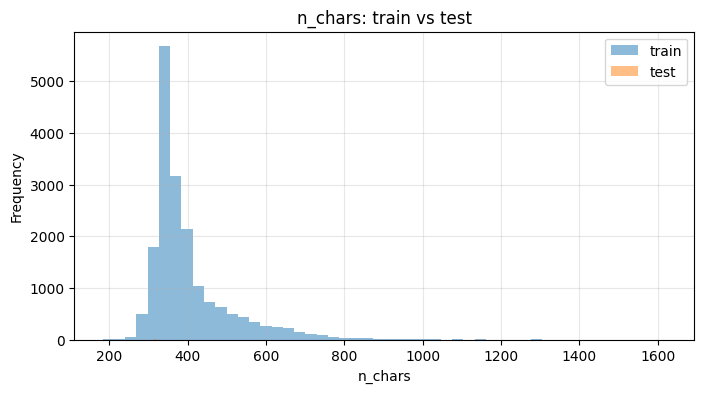

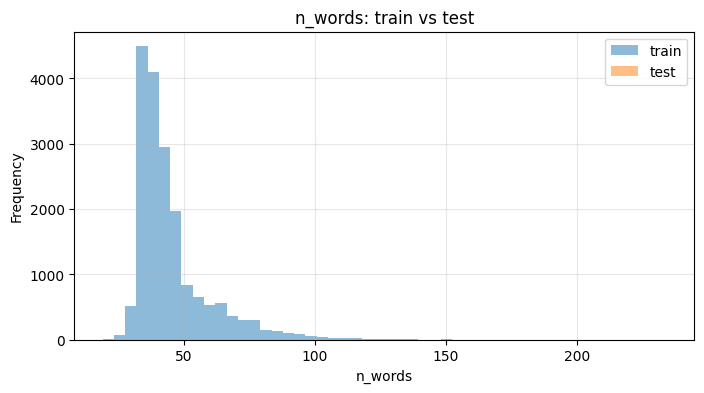

In [13]:
# =========================
# 8. Train vs test length comparison
# =========================
compare_df = pd.DataFrame({
    "set": ["train"] * len(train_eda) + ["test"] * len(test_eda),
    "n_chars": pd.concat([train_eda["n_chars"], test_eda["n_chars"]], axis=0).values,
    "n_words": pd.concat([train_eda["n_words"], test_eda["n_words"]], axis=0).values,
})

for col in ["n_chars", "n_words"]:
    plt.figure(figsize=(8, 4))
    for s in ["train", "test"]:
        vals = compare_df.loc[compare_df["set"] == s, col]
        plt.hist(vals, bins=50, alpha=0.5, label=s)
    plt.title(f"{col}: train vs test")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 9) N-grams más frecuentes globales

In [14]:
# =========================
# 9. Most common n-grams
# =========================
def get_top_ngrams(texts, ngram_range=(1, 1), top_k=30, min_df=3):
    vec = CountVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b\w+\b",
        min_df=min_df
    )
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    
    top_idx = counts.argsort()[::-1][:top_k]
    return pd.DataFrame({
        "ngram": vocab[top_idx],
        "count": counts[top_idx]
    })

print("Top unigrams:")
display(get_top_ngrams(train_eda["report"].fillna(""), ngram_range=(1, 1), top_k=40, min_df=3))

print("Top bigrams:")
display(get_top_ngrams(train_eda["report"].fillna(""), ngram_range=(2, 2), top_k=40, min_df=3))

Top unigrams:


,ngram,count
0,não,52123
1,calcificações,34025
2,se,26443
3,análise,26392
4,comparativa,26378
5,alterações,25678
6,significativas,25593
7,observam,25500
8,esparsas,23646
9,de,18319


Top bigrams:


,ngram,count
0,análise comparativa,26350
1,não se,25569
2,alterações significativas,25517
3,se observam,25461
4,indicação clínica,18138
5,regiões axilares,17432
6,não apresentam,17391
7,apresentam alterações,17382
8,axilares não,17381
9,as regiões,17348


## 10) N-grams distintivos por clase

In [15]:
# =========================
# 10. Class-specific TF-IDF clues
# =========================
def top_tfidf_terms_per_class(df, text_col="report", target_col="target", ngram_range=(1,2), top_k=20, min_df=3):
    results = {}
    
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r"(?u)\b\w+\b"
    )
    
    X = vectorizer.fit_transform(df[text_col].fillna(""))
    vocab = np.array(vectorizer.get_feature_names_out())
    
    for cls in sorted(df[target_col].unique()):
        cls_mask = (df[target_col] == cls).values
        cls_mean = np.asarray(X[cls_mask].mean(axis=0)).ravel()
        non_cls_mean = np.asarray(X[~cls_mask].mean(axis=0)).ravel()
        diff = cls_mean - non_cls_mean
        
        top_idx = diff.argsort()[::-1][:top_k]
        results[cls] = pd.DataFrame({
            "term": vocab[top_idx],
            "tfidf_diff": diff[top_idx]
        })
    return results

class_terms = top_tfidf_terms_per_class(train_eda, text_col="report", target_col="target", ngram_range=(1,2), top_k=20, min_df=5)

for cls, df_cls in class_terms.items():
    print(f"\n========== TARGET {cls} ==========")
    display(df_cls)


========== TARGET 0 ==========


,term,tfidf_diff
0,da mama,0.065127
1,mama,0.064962
2,da,0.055154
3,cm,0.053362
4,medindo,0.052857
5,no,0.048478
6,quadrante,0.047431
7,nódulo,0.045775
8,no quadrante,0.042796
9,medindo cerca,0.042117



========== TARGET 1 ==========


,term,tfidf_diff
0,nódulos não,0.095862
1,não,0.043915
2,lipossubstituídas não,0.037742
3,agrupadas as,0.035220
4,análise,0.034998
5,análise comparativa,0.034936
6,comparativa,0.034849
7,para análise,0.034766
8,comparativa mamografias,0.034752
9,disponíveis para,0.034701



========== TARGET 2 ==========


...

,term,tfidf_diff
0,cm,0.063770
1,mama,0.063469
2,da mama,0.058978
3,da,0.054182
4,0,0.044625
5,no,0.044023
6,localizadas,0.043221
7,extensão,0.042506
8,esparsas as,0.040004
9,extensão de,0.039900



========== TARGET 5 ==========


,term,tfidf_diff
0,cm,0.081811
1,espiculado,0.070926
2,nódulo espiculado,0.065001
3,2,0.062156
4,e,0.061897
5,medindo,0.061838
6,nódulo,0.057999
7,retração,0.057682
8,5,0.056228
9,da,0.054626



========== TARGET 6 ==========


,term,tfidf_diff
0,carcinoma,0.085310
1,invasivo,0.068991
2,de carcinoma,0.057780
3,resultado,0.056913
4,nódulo,0.055375
5,irregular,0.049454
6,carcinoma mamário,0.047239
7,mama,0.046913
8,com resultado,0.045867
9,espiculado,0.045519


## 11) Tokens clínicos clave por clase11) Tokens clínicos clave por clase

In [16]:
# =========================
# 11. Domain keyword frequency by class
# =========================
keywords = [
    "calcifica", "nódulo", "nodulo", "massa", "assimetria", "distorção", "distorcao",
    "arquitetural", "microcalcifica", "lesão", "lesao", "mamária", "mamaria",
    "direita", "esquerda", "bilateral", "linfonodo", "axila",
    "suspeit", "biops", "acompanh", "controle", "ultrass", "resson",
    "inconclus", "compar", "estável", "estavel", "benign", "malign"
]

def keyword_freq_by_class(df, text_col="report_norm", target_col="target", keywords=None):
    rows = []
    for cls in sorted(df[target_col].unique()):
        subset = " ".join(df.loc[df[target_col] == cls, text_col].tolist())
        for kw in keywords:
            cnt = len(re.findall(re.escape(kw), subset))
            rows.append([cls, kw, cnt])
    out = pd.DataFrame(rows, columns=["target", "keyword", "count"])
    return out

kw_df = keyword_freq_by_class(train_eda, keywords=keywords)
pivot_kw = kw_df.pivot(index="keyword", columns="target", values="count").fillna(0).astype(int)
display(pivot_kw)

target,0,1,2,3,4,5,6
keyword,,,,,,,
acompanh,0,0,8,5,0,0,0
arquitetural,24,15,291,34,10,3,17
assimetria,178,19,802,283,27,2,14
axila,593,683,16071,696,220,34,42
benign,577,4,15949,680,198,26,39
bilateral,10,5,209,20,2,0,1
biops,2,0,67,5,2,0,22
calcifica,1187,684,31820,1463,470,56,85
compar,1019,1113,23122,945,320,44,60


## 12) Duplicados y near-duplicates

In [18]:
# =========================
# 12. Exact duplicate reports
# =========================
dup_reports = train_eda.groupby("report").agg(
    n=("ID", "count"),
    unique_targets=("target", "nunique"),
    targets=("target", lambda x: sorted(x.unique().tolist()))
).reset_index()

dup_reports = dup_reports[dup_reports["n"] > 1].sort_values(["unique_targets", "n"], ascending=[False, False])

print("Number of duplicated report texts in train:", len(dup_reports))
display(dup_reports.head(20))

Number of duplicated report texts in train: 787


,report,n,unique_targets,targets
1576,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias an...,979,2,"[1, 2]"
1536,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao ...,564,2,"[1, 2]"
2264,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias anteriores não disponíveis para anális...,148,2,"[1, 2]"
4086,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias anteriores não dis...",103,2,"[1, 2]"
5578,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rNão se observam microcalcificações pleomórficas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao exame de <DATA>, não se observam alter...",28,2,"[1, 2]"
4076,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao exame de <DATA>,...",19,2,"[1, 2]"
8302,"Indicação clínica:\n\rrastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao exame de <DATA>, não se observam alte...",7,2,"[1, 2]"
8598,"Indicação clínica:\n\rrastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias anteriores não disp...",5,2,"[1, 2]"
3536,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rCalcificações benignas esparsas.\n\r Não se observam calcificações suspeitas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm ...",2,2,"[0, 2]"
6001,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas predominantemente lipossubstituídas.\n\rCalcificações puntiformes agrupadas em região retroareolar esquerda, com extensão de 0,4 cm, retrospectivamente estável em relação ao exame de <DATA>.\n\rNão se observam microcalcificações pleomórfi...",2,2,"[2, 3]"


### Near-duplicates simples

In [20]:
# =========================
# 12B. Near-duplicate approximation
# =========================
def light_normalize_for_dup(x):
    x = str(x).lower()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-zà-ÿ0-9 ]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

train_eda["report_dup_norm"] = train_eda["report"].fillna("").apply(light_normalize_for_dup)

dup_norm = train_eda.groupby("report_dup_norm").agg(
    n=("ID", "count"),
    unique_targets=("target", "nunique"),
    example_text=("report", "first"),
    targets=("target", lambda x: sorted(x.unique().tolist()))
).reset_index()

dup_norm = dup_norm[(dup_norm["n"] > 1) & (dup_norm["report_dup_norm"] != "")]
dup_norm = dup_norm.sort_values(["unique_targets", "n"], ascending=[False, False])

print("Potential duplicated / normalized duplicated reports:", len(dup_norm))
display(dup_norm.head(20))

Potential duplicated / normalized duplicated reports: 739


,report_dup_norm,n,unique_targets,example_text,targets
1025,indicação clínica rastreamento achados mamas com densidades fibroglandulares esparsas calcificações benignas esparsas não se observam calcificações suspeitas agrupadas as regiões axilares não apresentam alterações significativas análise comparativa mamografias anteriores não disponíveis para aná...,1039,2,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias an...,"[1, 2]"
976,indicação clínica rastreamento achados mamas com densidades fibroglandulares esparsas calcificações benignas esparsas não se observam calcificações suspeitas agrupadas as regiões axilares não apresentam alterações significativas análise comparativa em relação ao exame de data não se observam alt...,640,2,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao ...,"[1, 2]"
3529,indicação clínica rastreamento achados mamas heterogeneamente densas o que pode ocultar pequenos nódulos calcificações benignas esparsas não se observam calcificações suspeitas as regiões axilares não apresentam alterações significativas análise comparativa em relação ao exame de data não se obs...,228,2,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm r...","[0, 2]"
1819,indicação clínica rastreamento achados mamas com densidades fibroglandulares esparsas não se observam calcificações suspeitas agrupadas as regiões axilares não apresentam alterações significativas análise comparativa mamografias anteriores não disponíveis para análise comparativa,152,2,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias anteriores não disponíveis para anális...,"[1, 2]"
3861,indicação clínica rastreamento achados mamas heterogeneamente densas o que pode ocultar pequenos nódulos não se observam calcificações suspeitas agrupadas as regiões axilares não apresentam alterações significativas análise comparativa mamografias anteriores não disponíveis para análise comparativa,108,2,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rMamografias anteriores não dis...","[1, 2]"
1806,indicação clínica rastreamento achados mamas com densidades fibroglandulares esparsas não se observam calcificações suspeitas agrupadas as regiões axilares não apresentam alterações significativas análise comparativa em relação ao exame de data não se observam alterações significativas,38,2,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rEm relação ao exame de <DATA>, não se observam alt...","[1, 2]"
5416,indicação clínica rastreamento achados mamas parcialmente lipossubstituídas não se observam microcalcificações pleomórficas agrupadas as regiões axilares não apresentam alterações significativas análise comparativa em relação ao exame de data não 

## 13) Reportes extremos

In [22]:
# =========================
# 13. Extreme cases
# =========================
print("Shortest reports:")
display(train_eda.sort_values("n_words", ascending=True)[["ID", "target", "n_words", "n_chars", "report"]].head(10))

print("Longest reports:")
display(train_eda.sort_values("n_words", ascending=False)[["ID", "target", "n_words", "n_chars", "report"]].head(10))

Shortest reports:


,ID,target,n_words,n_chars,report
2956,Acc3670,2,19,183,Indicação clínica:\n\rginecomastia.\n\rAchados:\n\rMamas com tecido fibroglandular difuso.\n\rCalcificações benignas esparsas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
14403,Acc17883,1,22,210,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas com densidades fibroglandulares esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
16209,Acc20168,1,23,237,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas predominantemente adiposas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rLinfonodos parcialmente visualizados nas regiões axilares.\n\rAnálise comparativa:\n\rPrimeira mamografia.\n\r
1971,Acc2456,2,23,217,Indicação clínica:\n\rginecomastia.\n\rAchados:\n\rMamas com tecido fibroglandular retroareolar bilateral.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
10250,Acc12688,1,24,244,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas predominantemente lipossubstituídas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rPrimeiro exame.\n\r
1786,Acc2217,2,24,236,Indicação clínica:\n\r primeiro exame.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
5714,Acc7070,2,24,236,Indicação clínica:\n\r Primeiro exame.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
2015,Acc2510,2,24,236,Indicação clínica:\n\r primeiro exame.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
2879,Acc3570,2,24,236,Indicação clínica:\n\r primeiro exame.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\r
84,Acc106,3,24,193,Indicação clínica:\n\r reavaliação de alteração observada à mamografia de <DATA>.\n\rAchados:\n\rCalcificações puntiformes e redondas agrupadas na junção dos quadrantes inferiores da mama esquerda.\n\r


Longest reports:


,ID,target,n_words,n_chars,report
12506,Acc15502,2,234,1622,"RELATÓRIO INTEGRADO MAMOGRAFIA E ULTRASSONOGRAFIA MAMÁRIAIndicação clínica:\n\r rastreamento.\n\rMamografia:\n\rMamas heterogeneamente densas,o que pode ocultar pequenos nódulos.\n\rCalcificações benignas esparsas, algumas assumindo configuração em meia lua na incidência em perfil, sugerindo grã..."
436,Acc541,3,211,1287,"Indicação clínica:\n\r rastreamentoAchados:\n\rMamas parcialmente lipossubstituídas, com tecido fibroglandular heterogeneamente denso,o que diminui a sensibilidade da mamografia.\n\r Realizada complementação ultrassonográfica, que evidenciou nódulos sólidos circunscritos ovalados bilaterais, ass..."
4621,Acc5732,2,175,1305,"Indicação clínica:\n\rControle de nódulo na mama direita.\n\rNodulectomia prévia (<DATA>) à direita, cujo anatomopatológico mostrou fibrose estromal e hiperplasia ductal leve sem atipias e alteração de células colunares.\n\rAchados:\n\rMamas densas pelo predomínio do tecido fibroglandular o que ..."
16244,Acc20206,2,157,1193,"Indicação clínica:\n\rrastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rNódulo ovalado e circunscrito, localizado no quadrante inferomedial da mama esquerda, medindo cerca de 1,0 cm, descrito como estável desde <DATA> e que, segundo laudo anterio..."
15413,Acc19157,6,150,1153,"Indicação clínica:\n\r paciente com diagnóstico confirmado de carcinoma mamário invasivo na mama esquerda, em programação de QT neoadjuvante.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rNódulo espiculado associado a distorção arquitetural localizado no t..."
12488,Acc15478,5,148,1140,"RELATÓRIO INTEGRADO \t\t\t\t\t\t MAMOGRAFIA E ULTRASSONOGRAFIA MAMÁRIAIndicação clínica:\n\r rastreamento.\n\rMamografia:\n\rMamas com densidades fibroglandulares esparsas.\n\rNódulos de margens obscurecidas na região retroareolar e quadrante superolateral da mama esquerda, que correspondem a n..."
12220,Acc15149,3,145,1093,"Indicação clínica:\n\rLinfonodo axilar direito atípico.\n\r Pesquisa de neoplasia primária.\n\rDrenagem recente de abscesso na axila direita.\n\rAchados:\n\rLesão cutânea na mama esquerda, que se apresenta como lesão nodularna projeção dos quadrantes inferiores.\n\rMamas extremamente densas, o q..."
12852,Acc15934,3,141,1043,"Indicação clínica:\n\r rastreamento.\n\r Mastite na mama esquerda em <REMOVIDO>.\n\r Sem antecedente familiares.\n\r Câncer no peritônio em <REMOVIDO> <REMOVIDO>.\n\rRefere queixa palpável no quadrante inferomedial da mama esquerda.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode oculta..."
10947,Acc13553,3,138,1117,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas heterogeneamente densas, o que pode ocultar pequenos nódulos.\n\rCalcificações puntiformes e monomórficas com distribuição circular, medindo cerca de 0,4 cm , localizadas em dois grupamentos:\n\r1.\n\r Na junção dos quadrantes da mama dir..."
10809,Acc13384,3,137,1030,"Indicação clínica:\n\rControle de nódulos bilaterais.\n\rAchados:\n\rMarcador radiopaco na mama esquerda na projeção de lesão cutânea.\n\rMamas heterogeneamente densas, o que diminui a sensibilidade da mamografia.\n\rNa mama direita, nódulo parcialmente caracterizado no presente estudo, localiza..."


## 14) Posible fuga de información textual

In [23]:
# =========================
# 14. Leakage clue search
# =========================
suspicious_terms = [
    "bi-rads", "birads", "categoria", "categoria 0", "categoria 1", "categoria 2",
    "categoria 3", "categoria 4", "categoria 5", "categoria 6",
    "conclusão", "conclusao", "impressão", "impressao", "recomend",
    "controle em 6 meses", "biópsia", "biopsia", "alta suspeição", "alta suspeicao"
]

joined_text = " ".join(train_eda["report_norm"].tolist())

leak_counts = []
for term in suspicious_terms:
    cnt = len(re.findall(re.escape(term.lower()), joined_text))
    leak_counts.append([term, cnt])

leak_df = pd.DataFrame(leak_counts, columns=["term", "count"]).sort_values("count", ascending=False)
display(leak_df)

,term,count
16,biópsia,150
0,bi-rads,71
2,categoria,65
17,biopsia,63
14,recomend,62
5,categoria 2,47
6,categoria 3,7
3,categoria 0,4
1,birads,3
4,categoria 1,2


In [25]:
# Mostrar ejemplos con posibles términos sospechosos
suspect_regex = r"bi-rads|birads|conclus[aã]o|impress[aã]o|biops|6 meses|recomend"

suspect_rows = train_eda[train_eda["report_norm"].str.contains(suspect_regex, regex=True, na=False)]
print("Potentially suspicious rows:", suspect_rows.shape[0])
display(suspect_rows[["ID", "target", "report"]].head(20))

Potentially suspicious rows: 184


,ID,target,report
86,Acc108,3,Indicação clínica:\n\r Antecedente familiar positivo (mãe-ovário)Achados:\n\rMarcador radiopaco em lesão cutânea da mama esquerdaMamas densas pelo predomínio do tecido fibroglandular o que diminui a sensibilidade da mamografia.\n\rAssimetria focal localizada no quadrante superolateral da mama es...
124,Acc150,2,Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam calcificações suspeitas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rAnálise comparativa:\n\rComparação com exame de ...
371,Acc464,2,"Indicação clínica:\n\rrastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rNódulo ovalado com margens circunscritas, localizado no quadrante inferomedial da mama esquerda, medindo cerca de 1,5 cm, estável há 36 meses.\n\rCalcificações benignas esparsas.\n\rNão se observam calcif..."
461,Acc570,3,"Indicação clínica:\n\r reavaliação de alteração observada à mamografia de <DATA>Realizadas incidências craniocaudal e perfil compressão localizada na mama esquerda.\n\rAchados:\n\rImagem nodular, localizadana união dos quadrantes superiores da mama esquerda, medindo cerca de 1,2 cm,que persiste ..."
464,Acc573,6,"Indicação clínica:\n\r reavaliação de alteração observada à mamografia de <DATA>.\n\rRealizadas incidências com compressão localizada na mama esquerda.\n\rAchados:\n\rNódulo com limites imprecisos, medindo cerca de 0,7 cm, localizado na junção dos quadrantes inferiores da mama esquerda.\n\r Este..."
469,Acc579,2,"Indicação clínica:\n\r reavaliação de alteração observada à mamografia de <DATA>Realizadas incidências craniocaudal e mediolateral com compressão localizada na mama direita.\n\rAchados:\n\rAssimetria focal localizada no quadrante superolateral da mama direita, entremeada por tecido gorduroso, qu..."
564,Acc697,2,Indicação clínica:\n\r rastreamentoAchados:\n\rMamas densas pelo predomínio do tecido fibroglandular o que diminui a sensibilidade da mamografia.\n\rNão se observam microcalcificações pleomórficas agrupadas.\n\rCalcificações benignas esparsas.\n\r Nódulo de contornos parcialmente individualizado...
644,Acc799,0,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rImagem nodular, ovalada, de limites parcialmente definidos, medindo cerca de 0,8 cm, no quadrante superolateral esquerdo.\n\rCalcificações benignas esparsas.\n\r algumas vasculares.\n\rNão se observam ca..."
657,Acc818,0,Indicação clínica:\n\r rastreamentoAchados:\n\rMamas densas pelo predomínio do tecido fibroglandular o que diminui a sensibilidade da mamografia.\n\rNão se observam microcalcificações pleomórficas agrupadas.\n\rCalcificações benignas esparsas.\n\r Nódulos de contornos parcialmente individualizad...
709,Acc882,2,"Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam microcalcificações pleomórficas agrupadas.\n\rNódulo circunscrito no quadrante ínferomedial da mama esquerda, que à complementação ultrassonográfica co..."


## 15) Análisis básico de OOV / longitud estimada para Transformers

In [26]:
# =========================
# 15. Approx token length percentiles
# =========================
percentiles = [50, 75, 90, 95, 98, 99]

char_percentiles = np.percentile(train_eda["n_chars"], percentiles)
word_percentiles = np.percentile(train_eda["n_words"], percentiles)

print("Character percentiles:")
for p, v in zip(percentiles, char_percentiles):
    print(f"P{p}: {v:.1f}")

print("\nWord percentiles:")
for p, v in zip(percentiles, word_percentiles):
    print(f"P{p}: {v:.1f}")

Character percentiles:
P50: 364.0
P75: 423.0
P90: 542.0
P95: 629.0
P98: 712.6
P99: 778.0

Word percentiles:
P50: 40.0
P75: 48.0
P90: 64.0
P95: 75.0
P98: 87.0
P99: 96.0


## 16) Resumen automático del EDA

In [27]:
# =========================
# 16. Quick EDA summary
# =========================
print("===== QUICK SUMMARY =====")
print(f"Train rows: {len(train)}")
print(f"Test rows : {len(test)}")
print(f"Unique targets: {sorted(train['target'].unique())}")
print("\nTarget distribution:")
print(train["target"].value_counts(normalize=True).sort_index().round(4))

print("\nTrain text length summary:")
print(train_eda[["n_chars", "n_words"]].describe().round(2))

print("\nTest text length summary:")
print(test_eda[["n_chars", "n_words"]].describe().round(2))

print("\nExact duplicated reports in train:", train["report"].duplicated().sum())

===== QUICK SUMMARY =====
Train rows: 18272
Test rows : 4
Unique targets: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Target distribution:
target
0    0.0334
1    0.0379
2    0.8739
3    0.0390
4    0.0117
5    0.0016
6    0.0025
Name: proportion, dtype: float64

Train text length summary:
        n_chars   n_words
count  18272.00  18272.00
mean     400.67     44.90
std      103.23     14.22
min      183.00     19.00
25%      332.00     36.00
50%      364.00     40.00
75%      423.00     48.00
max     1622.00    234.00

Test text length summary:
       n_chars  n_words
count     4.00     4.00
mean    435.75    46.00
std     145.52    19.27
min     314.00    29.00
25%     317.00    29.75
50%     409.00    44.50
75%     527.75    60.75
max     611.00    66.00

Exact duplicated reports in train: 9141
